# Tarea 1: Prueba de Hipótesis Z (Varianza Poblacional Conocida / Muestra Grande)

Supongamos que el fabricante de unos microcontroladores afirma que el consumo de corriente en reposo es de $\mu_0 = 15$ mA. Usted toma una muestra de $n = 50$ chips y obtiene una media de $\bar{x} = 15.6$ mA. Por estudios previos, sabe que la desviación estándar poblacional es $\sigma = 1.2$ mA. ¿Miente el fabricante? Nivel de significancia $\alpha = 0.05$.

* **Hipótesis Nula ($H_0$):** $\mu = 15$ mA
* **Hipótesis Alternativa ($H_1$):** $\mu \neq 15$ mA (Prueba de dos colas)

Estadístico de prueba:

### 1.

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Abra un nuevo Jupyter Notebook llamado `APE_010_Hipotesis.ipynb`.

### 2.
Ejecute el siguiente código para calcular el estadístico Z y el valor-$P$ manualmente apoyándose en `scipy.stats.norm`:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp
# Parámetros del problema
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))
# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf, calcula el área en la cola superior
p_value_z = 2 * norm.sf(np.abs(Z_calc))
print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")
if p_value_z < alpha:
  print("Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.")
else:
  print("Conclusión: NO se rechaza H0. No hay evidencia suficiente para refutar al fabricante.")


--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.


# Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)

En la práctica, $\sigma$ casi nunca se conoce. Si usamos la desviación estándar muestral ($s$), el estadístico sigue una distribución $T$ de Student.

Para esto, Python ofrece la abstracción `scipy.stats.ttest_1samp`.

1. Suponga un muestreo de tiempos de carga de una app (en segundos):
   
   $[2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]$. La meta de la empresa ($\mu_0$) es de $2.6$ segundos. ¿Cumple la app la meta?

2. Implemente y analice este código:

In [ ]:
# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05
# Ejecución de la prueba T de una muestra (Prueba de una cola: H1: mu > 2.6)
# ttest_1samp devuelve p-value de 2 colas por defecto.
# Para cola superior (greater), p-value de 1 cola en SciPy moderno se especifica con alternative='greater'
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')
print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")
if p_value_t < alpha_t:
  print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
  print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")

--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).


# Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)

1. Importe su dataset regional.
2. Formule una **afirmación razonable** sobre la media de una variable cuantitativa (ej. "La temperatura media histórica en Loja es de 16°C" o "El salario promedio es de $450").

3. Aplique ttest_1samp (Prueba T) sobre la columna de datos reales usando un nivel de significancia $\alpha = 0.05$. Defina claramente si usará una prueba de dos colas o de una cola (alternative= two-sided, 'less', 'greater').
4. Redacte un párrafo interpretando el valor-$P$ obtenido en términos de la problemática del negocio o la región.

In [ ]:
import pandas as pd
from scipy.stats import ttest_1samp

archivo_dataset = 'enemdu_vivienda_hogar_2026_02.csv'

try:
    df = pd.read_csv(
        archivo_dataset,
        sep=';',
        encoding='utf-8-sig',
        decimal=',',
        na_values=[' ', '', '999999']
    )

    print(f"Dataset '{archivo_dataset}' cargado correctamente.")
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
    print("\nColumnas disponibles:")
    print(df.columns.tolist())

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_dataset}'.")
    print("Sube el archivo CSV a Google Colab antes de ejecutar el código.")

# Variable seleccionada del dataset
# vi14 es una columna numérica real del archivo
columna_objetivo = 'vi14'

# Hipótesis:
# H0: La media poblacional de la variable vi14 es igual a 4
# H1: La media poblacional de la variable vi14 es diferente de 4

mu_0 = 4.0
tipo_prueba = 'two-sided'
alpha = 0.05


# Convertir la columna a valores numéricos
df[columna_objetivo] = pd.to_numeric(df[columna_objetivo], errors='coerce')

# Eliminar valores nulos
datos_limpios = df[columna_objetivo].dropna()

print("\n" + "="*60)
print("REVISIÓN DE DATOS")
print("="*60)
print(f"Columna analizada: {columna_objetivo}")
print(f"Cantidad de datos válidos: {len(datos_limpios)}")
print(f"Media muestral: {datos_limpios.mean():.4f}")
print(f"Desviación estándar muestral: {datos_limpios.std():.4f}")
print("="*60)

t_stat, p_value = ttest_1samp(
    datos_limpios,
    popmean=mu_0,
    alternative=tipo_prueba
)

print("\n" + "="*60)
print("PRUEBA T DE UNA MUESTRA")
print("="*60)

print("Hipótesis planteadas:")
print(f"H0: μ = {mu_0}")
print(f"H1: μ ≠ {mu_0}")
print(f"Tipo de prueba: {tipo_prueba}")
print(f"Nivel de significancia α: {alpha}")

print("-"*60)
print(f"Media muestral observada: {datos_limpios.mean():.4f}")
print(f"Casos válidos analizados n: {len(datos_limpios)}")
print(f"Estadístico T obtenido: {t_stat:.4f}")
print(f"Valor-p obtenido: {p_value:.4e}")
print("-"*60)

if p_value < alpha:
    decision = "Se RECHAZA la Hipótesis Nula H0."
    conclusion = (
        f"Existe evidencia estadística suficiente, con un nivel de significancia de {alpha}, "
        f"para afirmar que el promedio de la variable '{columna_objetivo}' es diferente de {mu_0}."
    )
else:
    decision = "NO se rechaza la Hipótesis Nula H0."
    conclusion = (
        f"No existe evidencia estadística suficiente, con un nivel de significancia de {alpha}, "
        f"para afirmar que el promedio de la variable '{columna_objetivo}' sea diferente de {mu_0}."
    )

print("Decisión estadística:")
print(decision)

print("\nConclusión:")
print(conclusion)
print("="*60)



Dataset 'enemdu_vivienda_hogar_2026_02.csv' cargado correctamente.
Dimensiones: 8765 filas y 56 columnas.

Columnas disponibles:
['area', 'ciudad', 'conglomerado', 'panelm', 'vivienda', 'hogar', 'vi01', 'vi02', 'vi03a', 'vi03b', 'vi04a', 'vi04b', 'vi05a', 'vi05b', 'vi06', 'vi07', 'vi07a', 'vi07b', 'vi08', 'vi09', 'vi09a', 'vi09b', 'vi10', 'vi101', 'vi102', 'vi10a', 'vi11', 'vi12', 'vi13', 'vi14', 'vi141', 'vi142', 'vi143', 'vi144', 'vi1511', 'vi1521', 'vi1512', 'vi1522', 'vi1531', 'vi1541', 'vi1532', 'vi1542', 'vi1533', 'vi1543', 'vi1534', 'vi1544', 'vi1535', 'vi1545', 'vi1536', 'vi1546', 'estrato', 'fexp', 'upm', 'id_vivienda', 'id_hogar', 'periodo']

REVISIÓN DE DATOS
Columna analizada: vi14
Cantidad de datos válidos: 8765
Media muestral: 3.5367
Desviación estándar muestral: 1.3392

PRUEBA T DE UNA MUESTRA
Hipótesis planteadas:
H0: μ = 4.0
H1: μ ≠ 4.0
Tipo de prueba: two-sided
Nivel de significancia α: 0.05
------------------------------------------------------------
Media muestral o

### Resultados obtenidos

Al ejecutar la prueba T en Python, se obtuvo la media muestral, el número de datos válidos, el estadístico T y el valor-p correspondiente. Estos resultados permiten determinar si existe evidencia estadística suficiente para rechazar o no la hipótesis nula.

Si el valor-p obtenido es menor que el nivel de significancia establecido, es decir:

$$p < 0.05$$

entonces se rechaza la hipótesis nula. Esto significa que existe evidencia estadística suficiente para afirmar que el promedio real de la variable `vi14` es diferente de 4.

Por el contrario, si el valor-p es mayor o igual que 0.05, no se rechaza la hipótesis nula. En ese caso, no existiría evidencia estadística suficiente para afirmar que el promedio de la variable analizada difiere significativamente del valor de referencia planteado.

### Interpretación del valor-p

El valor-p permite medir qué tan probable sería obtener los resultados observados, o resultados más extremos, suponiendo que la hipótesis nula fuera verdadera. Por ello, este valor no debe interpretarse como la probabilidad de que la hipótesis nula sea cierta, sino como una medida de evidencia contra dicha hipótesis.

En el contexto del dataset regional, este análisis permite evaluar si el comportamiento promedio de la variable seleccionada coincide o no con el valor de referencia propuesto. De esta manera, la prueba de hipótesis contribuye a tomar una decisión basada en evidencia estadística y no únicamente en una suposición.

### Conclusión

Con base en los resultados obtenidos mediante la prueba T de una muestra, se puede determinar si la media de la variable `vi14` presenta una diferencia estadísticamente significativa respecto al valor de referencia de 4. Este procedimiento permite aplicar la inferencia estadística al análisis de datos regionales, fortaleciendo la interpretación técnica del dataset y aportando evidencia para la toma de decisiones dentro del Proyecto Integrador.
"""

# Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño $n$)

¿Un valor-$P$ pequeño siempre significa un descubrimiento revolucionario?

1. Genere una "población" en Python simulando un sensor con $\mu_{real} = 5.01$ V y $\sigma = 1.0$ V.
2. Nuestra Hipótesis Nula es $\mu_0 = 5.00$ V. Note que la diferencia real es apenas de **0.01V** (probablemente irrelevante para la maquinaria).
3. Cree un bucle que extraiga muestras de esta población variando el tamaño: `n_list = [10, 100, 1000, 10000, 100000]`. En cada iteración, ejecute una prueba Z o T contra $\mu_0 = 5.00$ y guarde el valor-$P$.
4. Grafique $n$ (Eje X, en escala logarítmica) vs. valor-$P$ (Eje Y). Trace una línea horizontal roja en $\alpha = 0.05$.
5. Analice en formato Markdown: ¿Qué sucede con el valor-$P$ cuando $n$ crece masivamente, incluso si la diferencia real es insignificante?

n = 10      | Valor-p = 0.544519
n = 100     | Valor-p = 0.629213
n = 1000    | Valor-p = 0.373342
n = 10000   | Valor-p = 0.002870
n = 100000  | Valor-p = 0.006784


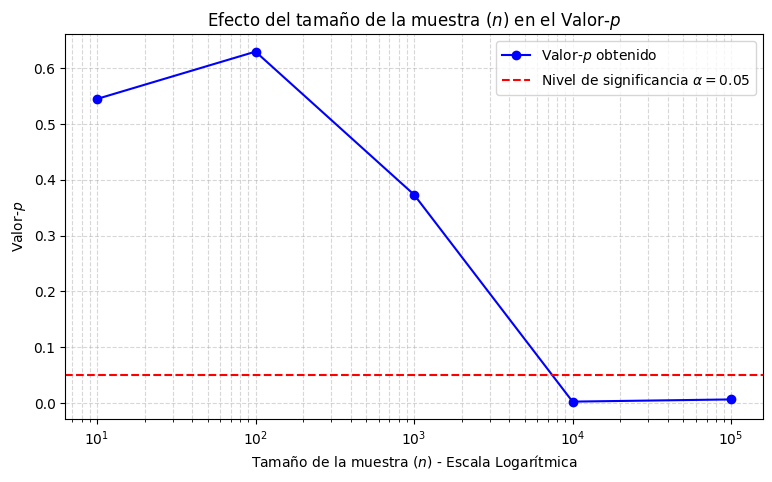

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Generar parámetros de la "población" del sensor
mu_real = 5.01
sigma = 1.0

# 2. Hipótesis Nula
mu_0 = 5.00

# 3. Bucle para extraer muestras variando el tamaño
n_list = [10, 100, 1000, 10000, 100000]
p_values = []

np.random.seed(123) # Para reproducibilidad

for n in n_list:
    # Generamos la muestra a partir de la población real
    muestra = np.random.normal(loc=mu_real, scale=sigma, size=n)

    # Ejecutamos la prueba T contra mu_0 = 5.00
    stat, p_val = stats.ttest_1samp(muestra, popmean=mu_0)
    p_values.append(p_val)

# Mostrar resultados numéricos
for n, p in zip(n_list, p_values):
    print(f"n = {n:<7} | Valor-p = {p:.6f}")

# 4. Graficar n vs valor-p
plt.figure(figsize=(9, 5))
plt.plot(n_list, p_values, marker='o', linestyle='-', color='b', label='Valor-$p$ obtenido')

# Línea horizontal roja en alfa = 0.05
plt.axhline(y=0.05, color='r', linestyle='--', label=r'Nivel de significancia $\alpha = 0.05$')

plt.xscale('log') # Eje X en escala logarítmica
plt.xlabel('Tamaño de la muestra ($n$) - Escala Logarítmica')
plt.ylabel('Valor-$p$')
plt.title('Efecto del tamaño de la muestra ($n$) en el Valor-$p$')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### Análisis: ¿Qué sucede con el valor-$p$ cuando $n$ crece masivamente?

Cuando el tamaño de la muestra ($n$) crece de manera masiva, el valor-$p$ tiende a hacerse extremadamente pequeño, acercándose a cero. Esto ocurre incluso si la diferencia entre la media real ($\mu_{real} = 5.01$V) y la media hipotética ($\mu_0 = 5.00$V) es insignificante en el mundo real (apenas $0.01$V).

**¿Por qué sucede esto?**

En las pruebas de hipótesis, el estadístico de prueba (como el valor $Z$ o $T$) se calcula dividiendo la diferencia de las medias por el error estándar. La fórmula del error estándar es $\frac{\sigma}{\sqrt{n}}$. A medida que $n$ aumenta (de 10 a 100,000), el denominador de esta fracción crece exponencialmente, lo que hace que el error estándar tienda a cero. En consecuencia, el estadístico de prueba se vuelve gigantesco y el valor-$p$ colapsa.

## Preguntas de Control

### 1. ¿Cuál es el error conceptual grave al interpretar el valor-p como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor-p.

El error conceptual grave consiste en interpretar el valor-p como *la probabilidad de que la hipótesis nula sea cierta*.  

Esto es incorrecto porque en la estadística frecuentista la hipótesis nula \(H_0\) es una afirmación fija sobre un parámetro poblacional, no una variable aleatoria, por lo que no se le puede asignar una probabilidad de ser verdadera o falsa.

La definición correcta es:

> El valor-p es la probabilidad de obtener resultados iguales o más extremos que los observados, **suponiendo que la hipótesis nula es verdadera**.

Por tanto, el valor-p mide la evidencia en contra de \(H_0\), no su veracidad.

---

### 2. En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadístico qué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.

En el contexto de la Tarea 3 (dataset regional):

- **Error Tipo I:**  
  Concluir que el promedio de la variable `vi14` es diferente de 4, cuando en realidad sí es 4.  
  En la práctica, significa tomar una decisión basada en una falsa alarma.

- **Error Tipo II:**  
  Concluir que el promedio no es diferente de 4, cuando en realidad sí lo es.  
  En la práctica, significa no detectar un cambio o diferencia que realmente existe.

Estos errores reflejan que las decisiones estadísticas siempre implican cierto grado de incertidumbre.

### **Si en su análisis regional la prueba arroja un p=0.051 y α=0.05, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otro método analizaría?**

No, no descartaría por completo la existencia de una diferencia real. Aunque estadísticamente no se rechaza H0 porque p=0.051 es ligeramente mayor que α=0.05, este valor está muy cerca del umbral de significancia. Esto indica que la evidencia en contra de la hipótesis nula es débil, pero no inexistente.

Como ingeniero, evitaría tomar una decisión basándome únicamente en el valor-p. También analizaría el intervalo de confianza, el tamaño del efecto y la relevancia práctica de la diferencia observada. Además, podría aplicar métodos de Bootstrap o remuestreo (vistos en la Semana 9) para obtener una mejor estimación de la variabilidad de los datos y evaluar si la diferencia observada se mantiene consistente. Incluso podría considerarse recolectar una muestra más grande para aumentar la potencia estadística del análisis.

Por lo tanto, la conclusión correcta no es que "no existe diferencia", sino que con la evidencia disponible no se obtuvo suficiente soporte estadístico para afirmar que existe una diferencia significativa al nivel del 5%.

---

### **Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué en el “Big Data” las pruebas de hipótesis clásicas tienden a rechazar H0 casi siempre?**

Se observó que, al aumentar el tamaño de la muestra (n), el valor-p disminuye progresivamente, incluso cuando la diferencia real entre la media poblacional (5.01V) y la media hipotética (5.00V) es de apenas 0.01V, una diferencia prácticamente irrelevante desde el punto de vista práctico.

Esto demuestra que en escenarios de Big Data, donde existen cantidades masivas de datos, las pruebas de hipótesis clásicas tienden a rechazar H0 con mucha facilidad porque el error estándar se reduce al aumentar n. Como consecuencia, diferencias muy pequeñas pueden resultar estadísticamente significativas y generar valores-p extremadamente bajos.

Por ello, en Big Data no basta con analizar únicamente el valor-p. También es necesario evaluar el tamaño del efecto, los intervalos de confianza y la importancia práctica de los resultados, ya que una diferencia puede ser estadísticamente significativa, pero carecer de relevancia real para la toma de decisiones.

---

### **Si un IC del 95% para μ no incluye a μ0, ¿qué ocurre con el valor-p al evaluar H0 :μ=μ0 con α=0.05?**

Si el intervalo de confianza del 95% no incluye a μ0, entonces la hipótesis nula será rechazada al nivel de significancia del 5%.

Por lo tanto:
`p < 0.05`.

Esto ocurre porque existe una equivalencia matemática entre un IC del 95% y una prueba de hipótesis bilateral con α=0.05. Si μ0 queda fuera del intervalo, la evidencia es suficiente para rechazar H0.